In [19]:
import json
import pandas as pd

# 파일 경로
path = r"C:\Users\82109\OneDrive\바탕 화면\LexicoGraphy and GenAI\Lex_Project\Taboo-Language\kold_v1.json"


with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

In [20]:
df = pd.DataFrame(data)

In [21]:
df.shape

(40429, 11)

In [22]:
df['OFF_span'] = df['OFF_span'].str.strip()
df['OFF_span'] = df['OFF_span'].replace('', None)

In [23]:
df['TGT_span'] = df['TGT_span'].str.strip()
df['TGT_span'] = df['TGT_span'].replace('', None)

In [24]:
df_off = df[df['OFF_span'].notna()]

In [25]:
df_span = df[df['OFF'] == True].copy()

df_span['OFF_span'] = df_span['OFF_span'].str.strip()
df_span = df_span[df_span['OFF_span'] != ""]

In [26]:
# Tokenization with regex
import re
from collections import Counter

off_series = df['OFF_span'].dropna().astype(str)

tokens = []
for span in off_series:
    span = span.strip()
    if not span:
        continue
    
    # 공백 기준 분리
    for tok in span.split():
        # 한글/영문/숫자만 남기기
        tok = re.sub(r"[^0-9A-Za-z가-힣]", "", tok)
        if tok:
            tokens.append(tok)

counter = Counter(tokens)
counter.most_common(100)

[('왜', 455),
 ('다', 410),
 ('진짜', 325),
 ('그냥', 299),
 ('좀', 261),
 ('하는', 233),
 ('무슨', 223),
 ('더', 201),
 ('이', 200),
 ('참', 200),
 ('나라', 199),
 ('그', 199),
 ('하고', 187),
 ('이런', 185),
 ('또', 161),
 ('없는', 147),
 ('같은', 139),
 ('뭔', 131),
 ('너무', 129),
 ('안', 124),
 ('정말', 121),
 ('이게', 120),
 ('니들이', 113),
 ('그렇게', 110),
 ('없다', 109),
 ('제발', 109),
 ('뭐', 108),
 ('저런', 107),
 ('페미', 104),
 ('말고', 103),
 ('절대', 102),
 ('누가', 102),
 ('어떻게', 99),
 ('할', 98),
 ('하지', 92),
 ('나라를', 92),
 ('얼마나', 92),
 ('저', 91),
 ('많이', 89),
 ('한다', 89),
 ('있는', 87),
 ('못', 87),
 ('수', 87),
 ('미친', 85),
 ('것', 85),
 ('잘', 84),
 ('니가', 84),
 ('정신', 83),
 ('해라', 83),
 ('한', 83),
 ('지들', 81),
 ('아주', 80),
 ('제대로', 80),
 ('지들이', 80),
 ('이제', 79),
 ('하면', 79),
 ('이슬람', 77),
 ('나라가', 77),
 ('정신병', 76),
 ('사람', 75),
 ('말', 75),
 ('거', 74),
 ('니들', 74),
 ('사람이', 72),
 ('돈', 72),
 ('니', 70),
 ('난민', 70),
 ('동성애', 70),
 ('악법', 69),
 ('개', 69),
 ('한국', 68),
 ('있네', 68),
 ('쓰레기', 66),
 ('아님', 65),
 ('뭘', 65),
 ('아

In [27]:
# 1. OFF_span phrase 상위 30개
from collections import Counter

off_phrases = (
    df['OFF_span']
    .dropna()
    .astype(str)
    .str.strip()
)
off_phrases = off_phrases[off_phrases != ""]
print(Counter(off_phrases).most_common(30))


[('정신병', 23), ('역겹다', 10), ('문재앙', 9), ('미친', 7), ('한심하다', 7), ('빨갱이', 6), ('쓰레기', 6), ('정신병이다', 5), ('기레기', 5), ('존나', 5), ('헬조선', 4), ('미쳤네', 4), ('메갈', 4), ('개독', 4), ('꼴페미', 4), ('추하다', 4), ('썩어빠진', 4), ('웃기네', 4), ('짱깨', 3), ('무식한', 3), ('꺼져', 3), ('사회악이다', 3), ('미친것들', 3), ('극혐', 3), ('꼬라지', 3), ('꼰대', 3), ('빨갱이들', 3), ('악법', 3), ('개소리', 3), ('대깨문', 3)]


In [28]:
import re
from collections import Counter

stopwords = {
    '왜','다','진짜','그냥','좀','하는','무슨','더','이','참','그','하고','이런','또',
    '없는','같은','뭔','너무','안','정말','이게','그렇게','없다','제발','뭐','저런',
    '말고','절대','누가','어떻게','할','하지','얼마나','저','많이','한다','있는','못',
    '수','것','잘','한','아주','제대로','이제','하면','사람','말','거','아님','뭘',
    '아니라','그럼','그게','걍','사람들','없고','아닌가','소리','아니고','아','기사',
    '안된다','무조건','자기','가서','이렇게','하네','지금','보고','게','그만','알고'
}

def get_top_tokens(series, topn=30):
    tokens = []
    for span in series.dropna().astype(str):
        for tok in span.split():
            tok = re.sub(r"[^0-9A-Za-z가-힣]", "", tok)
            if tok and tok not in stopwords and len(tok) > 1:
                tokens.append(tok)
    return Counter(tokens).most_common(topn)

# 전체 OFF_span
get_top_tokens(df['OFF_span'], topn=50)

[('나라', 199),
 ('니들이', 113),
 ('페미', 104),
 ('나라를', 92),
 ('미친', 85),
 ('니가', 84),
 ('정신', 83),
 ('해라', 83),
 ('지들', 81),
 ('지들이', 80),
 ('이슬람', 77),
 ('나라가', 77),
 ('정신병', 76),
 ('니들', 74),
 ('사람이', 72),
 ('난민', 70),
 ('동성애', 70),
 ('악법', 69),
 ('한국', 68),
 ('있네', 68),
 ('쓰레기', 66),
 ('여성', 61),
 ('세금', 56),
 ('역시', 56),
 ('남자', 53),
 ('차별', 52),
 ('안되는', 52),
 ('이상한', 51),
 ('여자', 51),
 ('수준', 51),
 ('보면', 50),
 ('대한민국', 50),
 ('있다', 50),
 ('민주당', 50),
 ('여자가', 50),
 ('같이', 49),
 ('모르는', 49),
 ('그런', 49),
 ('말이', 48),
 ('아니냐', 48),
 ('국민들', 48),
 ('니네', 48),
 ('남자가', 48),
 ('아니면', 48),
 ('젠더', 47),
 ('중국', 47),
 ('우리', 47),
 ('있나', 47),
 ('때문에', 47),
 ('제일', 47)]

In [ ]:
# feminist
import re
from collections import Counter

sub = df[df['GRP'].astype(str).str.contains('feminist', case=False, na=False)]

tokens = []
for span in sub['OFF_span'].dropna().astype(str):
    for tok in span.split():
        tok = re.sub(r"[^0-9A-Za-z가-힣]", "", tok)
        if tok and tok not in stopwords and len(tok) > 1:
            tokens.append(tok)

Counter(tokens).most_common(30)

[('페미', 72),
 ('정신병', 53),
 ('페미가', 37),
 ('페미들', 31),
 ('페미는', 30),
 ('페미니즘', 28),
 ('메갈', 18),
 ('페미들이', 16),
 ('꼴페미', 16),
 ('니들이', 16),
 ('페미니즘은', 13),
 ('지들이', 13),
 ('페미를', 12),
 ('페미들아', 11),
 ('여성', 11),
 ('지들', 11),
 ('페미들은', 9),
 ('여자가', 9),
 ('웅앵웅', 9),
 ('보면', 9),
 ('정신병이다', 9),
 ('아니면', 9),
 ('한국', 8),
 ('나라', 8),
 ('젠더', 8),
 ('페미의', 8),
 ('모르는', 8),
 ('남혐', 8),
 ('정신병자', 8),
 ('페미니스트', 8)]

In [30]:
sub.loc[sub['OFF_span'].notna(), ['title', 'comment', 'OFF_span', 'TGT_span', 'GRP']].sample(20, random_state=42)

,title,comment,OFF_span,TGT_span,GRP
12558,근거 없는 ‘남혐’ 정치인·언론 타고 공론장으로…‘페미니즘 백래시’,찡찡 대ㅋㅋㅋ 님들도 했잖음? 기안 84 이루다 등등 님들이 하면 괜춘이고 남자들 ...,"찡찡 대ㅋㅋㅋ 님들도 했잖음?, 찡찡대는 거임?ㅋㅋㅋ",None,others-feminist
27220,[신지예의 정치포커스] 메갈만물설과 백래시,진짜 수준낮은 백래시에 한숨이 나올 지경이네요.,수준낮은 백래시에 한숨이 나올 지경이네요.,None,others-feminist
22908,"페미니스트 509명 ""포괄적 차별금지법이 혐오정치 끝낼 유일한 해법""",여기 있는 명단은 페미들 명단이다 이거네.잘 봐놔야겠다.,여기 있는 명단은 페미들 명단이다 이거네,None,others-feminist
13175,엄마는 어쩌다 여성혐오를 하게 됐을까,"페미의 악영향이 다른게 아님, 이런 당연한 내용을 봐도 불편하게 만든게 다름아닌 '...",이런 당연한 내용을 봐도 불편하게 만든게 다름아닌 '그녀들'이라는 거지,페미,others-feminist
12574,무심코 썼던 이모티콘이 '남혐'이라고?… 일상으로 스며든 '젠더 갈등',모르면 젠더감수성이 부족한거임 공부해야지그들이 만든 불편월드에서 다같이 평등하게 불편하자,"모르면 젠더감수성이 부족한거임, 그들이 만든 불편월드에서 다같이 평등하게 불편하자",None,others-feminist
37740,"""여성 반라사진 삭제는 성차별"" 여성단체 상의 탈의 퍼포먼스 / 연합뉴스 (Yonh...",왜 저런거 하는친구들은 항상 하나같이 이쁜친구들이 없을까 정말 아이러니,이쁜친구들이 없을까 정말 아이러니,None,others-feminist
16528,"국민의힘, 여성 지지율 급락·남성 지지율은 보합... '이남자 전략' 실패?",대한민국 페미 2천만설 ㅋㅋㅋㅋㅋ,대한민국 페미 2천만설 ㅋㅋㅋㅋㅋ,페미,others-feminist
11123,"CNN 한국의 젊은 남성들, 페미니즘과 싸우고 있다 / YTN",아 됐고 페미 국자나해,국자나해,페미,others-feminist
17947,[드랍더이슈] 트랜스젠더 를 쫓아낸 페미니스트? 숙대서 트랜스젠더가 쫓겨난 진짜...,앞에 이것저것 갖다붙여도 페미는 페미다,"앞에 이것저것 갖다붙여도, 페미는 페미다","페미, 페미",others-feminist
29931,페미니즘이란 무엇인가···불붙은 젠더 논쟁,휴머니즘하고같단다...바보인증,바보인증,None,others-feminist


In [34]:
import re
from collections import Counter, defaultdict

stopwords = {
'왜','다','진짜','그냥','좀','하는','무슨','더','이','참','그','하고','이런','또',
'없는','같은','뭔','너무','안','정말','이게','그렇게','없다','제발','뭐','저런',
'말고','절대','누가','어떻게','할','하지','얼마나','저','많이','한다','있는','못',
'수','것','잘','한','아주','제대로','이제','하면','사람','말','거','아님','뭘',
'아니라','그럼','그게','걍','사람들','없고','아닌가','소리','아니고','아','기사',
'안된다','무조건','자기','가서','이렇게','하네','지금','보고','게','그만','알고'
}

grp_tokens = defaultdict(list)

for _, row in df.iterrows():

    grp = row['GRP']
    span = row['OFF_span']

    if pd.isna(grp) or pd.isna(span):
        continue

    for tok in str(span).split():
        tok = re.sub(r"[^0-9A-Za-z가-힣]", "", tok)

        if tok and tok not in stopwords and len(tok) > 1:
            grp_tokens[grp].append(tok)

grp_token_counts = {
    g: Counter(toks).most_common(20)
    for g, toks in grp_tokens.items()
}

grp_token_counts

{'others-feminist': [('페미', 71),
  ('정신병', 51),
  ('페미가', 37),
  ('페미들', 31),
  ('페미는', 30),
  ('페미니즘', 27),
  ('니들이', 16),
  ('페미들이', 15),
  ('메갈', 15),
  ('꼴페미', 15),
  ('페미니즘은', 13),
  ('페미를', 12),
  ('페미들아', 11),
  ('지들이', 11),
  ('지들', 11),
  ('여성', 10),
  ('여자가', 9),
  ('웅앵웅', 9),
  ('보면', 9),
  ('정신병이다', 9)],
 'others-others': [('인간들', 9),
  ('말이', 8),
  ('니들이', 8),
  ('여가부', 8),
  ('지들이', 8),
  ('니들', 7),
  ('수준', 7),
  ('완전', 7),
  ('기레기들', 7),
  ('기레기', 7),
  ('쓰레기', 6),
  ('세금으로', 6),
  ('나라', 6),
  ('다시', 6),
  ('지들', 6),
  ('전라도', 6),
  ('시민단체', 6),
  ('이상한', 6),
  ('있네', 6),
  ('하지말고', 5)],
 'gender-female': [('여자가', 18),
  ('여성', 17),
  ('여자', 16),
  ('군대', 15),
  ('여자는', 15),
  ('남자가', 14),
  ('남자', 14),
  ('여자들이', 13),
  ('여자들', 13),
  ('여자도', 10),
  ('똑같이', 7),
  ('남자들이', 7),
  ('남성', 7),
  ('니들이', 6),
  ('혐오', 6),
  ('그러면', 6),
  ('나라', 6),
  ('여자들은', 6),
  ('오또케', 6),
  ('대한민국', 6)],
 'gender-feminist & politics-progressive': [('페미당', 1),
  ('지지하는', 1),
  ('경우는', 1)

### Attack template 분석

In [ ]:
import re
from collections import Counter

templates = []

for span in df['OFF_span'].dropna():

    text = str(span)

    # 페미 -> TARGET 치환
    text = re.sub(r'페미\w*', 'TARGET', text)

    templates.append(text)

Counter(templates).most_common(30)

[('정신병', 23),
 ('TARGET', 16),
 ('역겹다', 10),
 ('문재앙', 9),
 ('꼴TARGET', 8),
 ('미친', 7),
 ('한심하다', 7),
 ('빨갱이', 6),
 ('쓰레기', 6),
 ('정신병이다', 5),
 ('기레기', 5),
 ('존나', 5),
 ('헬조선', 4),
 ('미쳤네', 4),
 ('메갈', 4),
 ('개독', 4),
 ('추하다', 4),
 ('썩어빠진', 4),
 ('웃기네', 4),
 ('짱깨', 3),
 ('무식한', 3),
 ('꺼져', 3),
 ('사회악이다', 3),
 ('미친것들', 3),
 ('극혐', 3),
 ('꼬라지', 3),
 ('꼰대', 3),
 ('TARGET?', 3),
 ('빨갱이들', 3),
 ('악법', 3)]

In [ ]:
# GRP 별로 OFF_span 분석
import re
from collections import Counter
import pandas as pd

grp_vocab = {}

for grp, sub in single_df.groupby("GRP_clean"):

    tokens = []

    for span in sub['OFF_span'].dropna():

        for tok in str(span).split():

            tok = re.sub(r"[^0-9A-Za-z가-힣]", "", tok)

            if len(tok) > 1:
                tokens.append(tok)

    grp_vocab[grp] = Counter(tokens).most_common(10)

grp_vocab

{'LGBTQ+': [('동성애', 42),
  ('동성애는', 27),
  ('그냥', 26),
  ('진짜', 26),
  ('조용히', 21),
  ('에이즈', 19),
  ('동성애를', 17),
  ('하고', 16),
  ('동성애가', 15),
  ('무슨', 15)],
 'age': [('나라', 3),
  ('도대체', 2),
  ('가서', 2),
  ('문제야', 2),
  ('젊은', 2),
  ('유리천장이', 2),
  ('라떼들이', 2),
  ('언능', 2),
  ('아주', 2),
  ('성평등', 1)],
 'asian': [('중국', 2),
  ('독도를', 2),
  ('꼬치', 1),
  ('큰줄', 1),
  ('아냐', 1),
  ('무식', 1),
  ('빼고', 1),
  ('솔까', 1),
  ('생긴거나', 1),
  ('체격이', 1)],
 'black': [('인종차별', 11),
  ('흑인이', 11),
  ('동양인', 8),
  ('흑인', 8),
  ('흑인들', 4),
  ('많이', 3),
  ('애들이', 3),
  ('존나', 3),
  ('이제', 3),
  ('지들이', 2)],
 'buddhism': [('하고', 2),
  ('부처에', 1),
  ('반하는', 1),
  ('자들이군요', 1),
  ('정치논리에', 1),
  ('놀아나는', 1),
  ('산에만', 1),
  ('계셔서', 1),
  ('세상물정을', 1),
  ('모르는데', 1)],
 'catholic': [('불에', 4),
  ('사탄의', 3),
  ('마귀', 3),
  ('모르고', 2),
  ('하는', 2),
  ('아주', 2),
  ('세상', 2),
  ('동시에', 2),
  ('한꺼번에', 2),
  ('마귀의', 2)],
 'chinese': [('중국', 18),
  ('중국이', 11),
  ('그냥', 8),
  ('짱깨', 7),
  ('중국인', 7),
  ('진짜', 7),

1️⃣ KOLD 공격 언어의 핵심 구조

지금 결과에서 가장 중요한 패턴은 이것이다.

공격은 단순 욕설이 아니라 “target → concept 연결” 구조로 나타난다.

Important sentence

Offensive language in KOLD is structured around target–concept associations, rather than simple profanity.

즉 구조가 이런 식이다.

TARGET → attack concept

예

feminist → 정신병
LGBTQ → 에이즈
islam → 테러
chinese → 짱깨
2️⃣ 그룹별 공격 프레임 (가장 중요한 부분)
① Feminist

주요 단어

페미
정신병
페미들
페미니즘

핵심 공격 구조

feminist → pathology framing

Important sentence

Feminist-related attacks frequently frame the target as mentally ill or irrational.

② LGBTQ+

주요 단어

동성애
에이즈

핵심 공격 구조

LGBTQ → disease framing

Important sentence

LGBTQ-related attacks often associate homosexuality with disease or moral corruption.

③ Islam

주요 단어

이슬람
테러
안된다

핵심 공격 구조

islam → terrorism framing

Important sentence

Islam is frequently framed through terrorism-related discourse.

④ Chinese / Korean-Chinese

주요 단어

짱깨
조선족
중국인

핵심 공격 구조

ethnicity → ethnic slur

Important sentence

Ethnic groups are commonly attacked through derogatory ethnic labels.

⑤ Christian

주요 단어

개독
교회
목사

핵심 공격 구조

christian → hypocritical religion framing

Important sentence

Christian-related attacks often rely on compound slurs targeting religious institutions.

⑥ Politics

progressive

민주당
좌파
정권

conservative

국짐당
국민의

핵심 구조

political target → party labeling

Important sentence

Political attacks are primarily realized through party or ideological labeling.

3️⃣ 중요한 언어학적 특징

지금 데이터에서 보이는 중요한 특징은 이것이다.

공격은 욕설 중심이 아니다

많은 hate dataset은

slur 중심

하지만 KOLD는

concept framing 중심

이다.

Important sentence

Offensive expressions in KOLD are often realized through ideological or conceptual framing, rather than explicit profanity.

4️⃣ 또 하나 보이는 특징

공격 단어는 크게 몇 가지 유형으로 나뉜다.

① Pathology attack
정신병
미친
② Disease framing
에이즈
③ Ethnic slur
짱깨
조선족
④ Ideological labeling
좌파
민주당
⑤ Disgust expression
역겹다
극혐

Important sentence

Offensive language can be categorized into pathology, disease framing, ethnic slurs, ideological labeling, and disgust expressions.

In [68]:
# 보완점 새로 추가
import re
from collections import Counter
import pandas as pd

# 1) 불용어: 결과 보고 계속 추가/수정해도 됨
stopwords = {
    "그냥", "진짜", "너무", "정말", "아주", "무슨", "이런", "저런",
    "하고", "하는", "하다", "해서", "하면", "하며", "한데", "같은",
    "없는", "있는", "있다", "없다", "도대체", "제발", "이제", "또",
    "좀", "왜", "뭐", "뭔", "뭘", "거", "것", "수", "더", "잘", "안",
    "나라", "사람", "사람들", "애들", "애들이", "니들", "지들", "쟤들",
    "우리", "너희", "걔들", "그들", "그냥", "이나", "이다", "아니다"
}

# 2) 조사/어미 단순 정규화용 suffix
#   완벽한 표제어화는 아니고, EDA용 heuristic
suffixes = [
    "으로는", "으로도", "으로만", "으로", "에서", "에게", "한테", "처럼",
    "까지", "부터", "라도", "마저", "조차", "밖에", "만큼", "보다",
    "이다", "입니다", "였다", "였다가", "이다", "인", "인데",
    "은", "는", "이", "가", "을", "를", "에", "의", "와", "과", "도", "만"
]

def normalize_token(tok: str) -> str:
    tok = str(tok).strip()
    tok = re.sub(r"[^0-9A-Za-z가-힣]", "", tok)

    if len(tok) <= 1:
        return ""

    # 조사/어미 제거 (긴 suffix부터 먼저)
    for suf in sorted(suffixes, key=len, reverse=True):
        if tok.endswith(suf) and len(tok) > len(suf) + 1:
            tok = tok[:-len(suf)]
            break

    return tok

def span_to_tokens(span: str):
    # 공백 기준 1차 분리
    raw_tokens = str(span).split()
    tokens = []

    for tok in raw_tokens:
        norm = normalize_token(tok)
        if not norm:
            continue
        if norm in stopwords:
            continue
        if len(norm) <= 1:
            continue
        tokens.append(norm)

    return tokens

grp_vocab = {}

for grp, sub in single_df.groupby("GRP_clean"):
    tokens = []

    # 해당 group에서 자주 target으로 등장하는 표현(TGT_span)을 모아서 제거
    tgt_tokens = set()
    for tgt in sub["TGT_span"].dropna():
        tgt_tokens.update(span_to_tokens(tgt))

    for span in sub["OFF_span"].dropna():
        span_tokens = span_to_tokens(span)

        for tok in span_tokens:
            # target reference 제거
            if tok in tgt_tokens:
                continue
            tokens.append(tok)

    grp_vocab[grp] = Counter(tokens).most_common(15)

grp_vocab


{'LGBTQ+': [('에이즈', 32),
  ('정신병', 21),
  ('조용히', 21),
  ('세상', 18),
  ('차별', 18),
  ('정상', 17),
  ('아닌', 16),
  ('하지', 15),
  ('이게', 15),
  ('누가', 14),
  ('악법', 14),
  ('차별금지법', 14),
  ('축제', 13),
  ('한다', 12),
  ('인간', 12)],
 'age': [('당신들', 2),
  ('가서', 2),
  ('문제야', 2),
  ('유리천장', 2),
  ('사회', 2),
  ('라떼들', 2),
  ('언능', 2),
  ('성평등', 1),
  ('어쩌고하는게', 1),
  ('토악질', 1),
  ('나온다', 1),
  ('꼰대같', 1),
  ('지적질뿐임', 1),
  ('니네', 1),
  ('50', 1)],
 'asian': [('중국', 2),
  ('독도', 2),
  ('꼬치', 1),
  ('큰줄', 1),
  ('아냐', 1),
  ('빼고', 1),
  ('솔까', 1),
  ('생긴거나', 1),
  ('체격', 1),
  ('약하지', 1),
  ('한통속', 1),
  ('엮는건', 1),
  ('저런거', 1),
  ('없냐', 1),
  ('마음', 1)],
 'black': [('인종차별', 15),
  ('동양', 8),
  ('경찰', 5),
  ('백인', 4),
  ('많이', 3),
  ('존나', 3),
  ('싫어하면서', 2),
  ('범죄', 2),
  ('하는데', 2),
  ('아시아', 2),
  ('때문', 2),
  ('차별하고', 2),
  ('못하게', 2),
  ('치킨', 2),
  ('하지', 2)],
 'buddhism': [('부처', 1),
  ('반하', 1),
  ('자들이군요', 1),
  ('정치논리', 1),
  ('놀아나', 1),
  ('산에', 1),
  ('계셔서', 1),
  ('세상물정', 1),
  

Important sentence

Different target groups are attacked through distinct conceptual frames.

feminist → pathology
LGBTQ → disease
islam → terrorism
chinese → ethnic slur
politics → ideological labeling

즉
target group → attack concept

패턴이 존재한다.

1️⃣ KOLD 공격 언어의 핵심 구조

지금 결과에서 가장 중요한 패턴은 이것이다.

공격은 단순 욕설이 아니라 “target → concept 연결” 구조로 나타난다.

Important sentence

Offensive language in KOLD is structured around target–concept associations, rather than simple profanity.

즉 구조가 이런 식이다.

TARGET → attack concept

예

feminist → 정신병
LGBTQ → 에이즈
islam → 테러
chinese → 짱깨
2️⃣ 그룹별 공격 프레임 (가장 중요한 부분)
① Feminist

주요 단어

페미
정신병
페미들
페미니즘

핵심 공격 구조

feminist → pathology framing

Important sentence

Feminist-related attacks frequently frame the target as mentally ill or irrational.

② LGBTQ+

주요 단어

동성애
에이즈

핵심 공격 구조

LGBTQ → disease framing

Important sentence

LGBTQ-related attacks often associate homosexuality with disease or moral corruption.

③ Islam

주요 단어

이슬람
테러
안된다

핵심 공격 구조

islam → terrorism framing

Important sentence

Islam is frequently framed through terrorism-related discourse.

④ Chinese / Korean-Chinese

주요 단어

짱깨
조선족
중국인

핵심 공격 구조

ethnicity → ethnic slur

Important sentence

Ethnic groups are commonly attacked through derogatory ethnic labels.

⑤ Christian

주요 단어

개독
교회
목사

핵심 공격 구조

christian → hypocritical religion framing

Important sentence

Christian-related attacks often rely on compound slurs targeting religious institutions.

⑥ Politics

progressive

민주당
좌파
정권

conservative

국짐당
국민의

핵심 구조

political target → party labeling

Important sentence

Political attacks are primarily realized through party or ideological labeling.

3️⃣ 중요한 언어학적 특징

지금 데이터에서 보이는 중요한 특징은 이것이다.

공격은 욕설 중심이 아니다

많은 hate dataset은

slur 중심

하지만 KOLD는

concept framing 중심

이다.

Important sentence

Offensive expressions in KOLD are often realized through ideological or conceptual framing, rather than explicit profanity.

4️⃣ 또 하나 보이는 특징

공격 단어는 크게 몇 가지 유형으로 나뉜다.

① Pathology attack
정신병
미친
② Disease framing
에이즈
③ Ethnic slur
짱깨
조선족
④ Ideological labeling
좌파
민주당
⑤ Disgust expression
역겹다
극혐

Important sentence

Offensive language can be categorized into pathology, disease framing, ethnic slurs, ideological labeling, and disgust expressions.

### group별 offensive token을 higher-level concept로 추상화해서, target-specific framing pattern 관찰하기

In [58]:
# seed mapping (개념 분류 테이블)

# =========================
# 1. seed concept mapping
# =========================

concept_map = {
    # -------- pathology / mental illness --------
    "정신병": "pathology",
    "정신병이다": "pathology",
    "정신병자": "pathology",
    "미친": "pathology",
    "미쳤네": "pathology",
    "정신": "pathology",
    "답없다": "pathology",

    # -------- disease / contamination --------
    "에이즈": "disease_frame",
    "인권타령에이즈": "disease_frame",
    "코로나": "disease_frame",

    # -------- disgust / contempt --------
    "역겹다": "disgust",
    "역겨운": "disgust",
    "극혐": "disgust",
    "추하다": "disgust",
    "꼬라지": "disgust",
    "꼬라지하고는": "disgust",
    "ㅉㅉㅉ": "disgust",
    "웃기네": "disgust",
    "한심하다": "disgust",
    "무식": "disgust",
    "무식한": "disgust",

    # -------- generic insult / dehumanization --------
    "쓰레기": "generic_insult",
    "기생충": "dehumanization",
    "사회악이다": "dehumanization",
    "사기꾼": "generic_insult",
    "성추행범": "criminalization",
    "개소리": "generic_insult",
    "꺼져": "exclusion",
    "해체하라": "exclusion",
    "폐지가": "exclusion",
    "폐지가답이다": "exclusion",
    "폐지가답이다": "exclusion",
    "차별받아": "exclusion",
    "차별받아마땅하다": "exclusion",

    # -------- gender / feminist slur --------
    "페미": "gender_slur",
    "페미가": "gender_slur",
    "페미들": "gender_slur",
    "페미는": "gender_slur",
    "페미들이": "gender_slur",
    "페미를": "gender_slur",
    "페미들아": "gender_slur",
    "페미들은": "gender_slur",
    "페미니즘": "gender_ideology",
    "페미니즘은": "gender_ideology",
    "페미니스트": "gender_ideology",
    "메갈": "gender_slur",
    "꼴페미": "gender_slur",
    "남혐": "gender_conflict",
    "젠더": "gender_ideology",
    "한남": "gender_slur",
    "한남들": "gender_slur",

    # -------- sexuality --------
    "동성애": "sexuality_frame",
    "동성애는": "sexuality_frame",
    "동성애를": "sexuality_frame",
    "동성애가": "sexuality_frame",

    # -------- religion / religious slur --------
    "이슬람": "religion_identity",
    "이슬람은": "religion_identity",
    "종교": "religion_identity",
    "개독": "religious_slur",
    "개독교": "religious_slur",
    "개신교": "religion_identity",
    "교회": "religion_identity",
    "목사가": "religion_identity",
    "하나님이": "religion_identity",
    "사탄의": "religious_demonization",
    "마귀": "religious_demonization",
    "마귀의": "religious_demonization",
    "부처에": "religion_identity",

    # -------- terrorism / security --------
    "테러": "terrorism_frame",
    "달레반": "terrorism_frame",

    # -------- ethnicity / race / nationality --------
    "짱깨": "ethnic_slur",
    "조선족": "ethnic_slur",
    "조선족은": "ethnic_slur",
    "중국": "nationality_identity",
    "중국이": "nationality_identity",
    "중국인": "nationality_identity",
    "중국으로": "outsider_frame",
    "동포": "ethnic_identity",
    "동포라고": "ethnic_identity",
    "동포는": "ethnic_identity",
    "흑인": "race_identity",
    "흑인이": "race_identity",
    "흑인들": "race_identity",
    "동양인": "race_identity",
    "인종차별": "race_discourse",
    "인도는": "nationality_identity",
    "인도가": "nationality_identity",
    "베트남": "nationality_identity",
    "독도를": "national_conflict",

    # -------- politics --------
    "문재앙": "political_slur",
    "빨갱이": "political_slur",
    "빨갱이들": "political_slur",
    "대깨문": "political_slur",
    "민주당": "political_identity",
    "좌파": "political_label",
    "더불어": "political_identity",
    "정권": "political_identity",
    "국짐당": "political_slur",
    "국짐": "political_slur",
    "국민의": "political_identity",
    "후보": "political_identity",
    "악법": "political_label",
    "기레기": "media_slur",

    # -------- migration / nation --------
    "난민": "immigration_frame",
    "나라": "national_frame",
    "나라를": "national_frame",
    "나라가": "national_frame",
    "나라로": "national_frame",
    "한국": "national_frame",
    "근본도없는한국": "national_frame",
    "근본도없는한국TARGET": "national_frame",

    # -------- gender-role discourse --------
    "여자가": "gender_role",
    "여성": "gender_role",
    "여자": "gender_role",
    "여자는": "gender_role",
    "남자가": "gender_role",
    "남자": "gender_role",
    "남자들": "gender_role",
    "군대": "gender_role",

    # -------- age / appearance / class --------
    "젊은": "age_discourse",
    "라떼들이": "age_discourse",
    "유리천장이": "gender_role",
    "대머리네": "appearance_attack",
    "대머리여": "appearance_attack",
    "썩은": "class_contempt",
    "썩어빠진": "class_contempt",
}

In [59]:
# 토큰 정규화 함수
import re

def normalize_token(tok: str) -> str:
    tok = str(tok).strip()
    tok = re.sub(r"[^0-9A-Za-z가-힣]", "", tok)

    # 자주 나오는 조사/어미 아주 단순 제거
    suffixes = [
        "들은", "들이", "들아", "들은", "들은", "들은",
        "은", "는", "이", "가", "을", "를", "와", "과",
        "으로", "로", "에서", "에게", "만", "도", "야"
    ]
    for s in sorted(suffixes, key=len, reverse=True):
        if tok.endswith(s) and len(tok) > len(s) + 1:
            tok = tok[:-len(s)]
            break

    return tok

In [60]:
from collections import Counter, defaultdict
import pandas as pd

grp_concept_counts = {}
unmapped_tokens = defaultdict(list)

for grp, word_list in grp_vocab.items():
    concept_counter = Counter()

    for word, cnt in word_list:
        norm = normalize_token(word)

        # 1차: 원형으로 매핑
        if word in concept_map:
            concept = concept_map[word]

        # 2차: normalize된 토큰으로 매핑
        elif norm in concept_map:
            concept = concept_map[norm]

        # 3차: 규칙 기반 fallback
        elif "페미" in norm:
            concept = "gender_slur"
        elif "동성애" in norm:
            concept = "sexuality_frame"
        elif "이슬람" in norm:
            concept = "religion_identity"
        elif "중국" in norm:
            concept = "nationality_identity"
        elif "조선족" in norm:
            concept = "ethnic_slur"
        elif "흑인" in norm:
            concept = "race_identity"
        elif "민주당" in norm or "좌파" in norm:
            concept = "political_label"
        elif "국짐" in norm or "국민의" in norm:
            concept = "political_label"
        elif "개독" in norm:
            concept = "religious_slur"
        elif "정신병" in norm or "미친" in norm:
            concept = "pathology"
        elif "테러" in norm:
            concept = "terrorism_frame"
        elif "에이즈" in norm:
            concept = "disease_frame"
        elif "난민" in norm:
            concept = "immigration_frame"
        elif "여자" in norm or "여성" in norm or "남자" in norm or "군대" in norm:
            concept = "gender_role"
        else:
            concept = "other_or_generic"
            unmapped_tokens[grp].append((word, cnt))

        concept_counter[concept] += cnt

    grp_concept_counts[grp] = concept_counter

# 표 형태로 보기
concept_df = pd.DataFrame(grp_concept_counts).fillna(0).astype(int).T
concept_df

,sexuality_frame,other_or_generic,disease_frame,national_frame,age_discourse,gender_role,nationality_identity,national_conflict,disgust,race_discourse,...,gender_slur,pathology,gender_ideology,terrorism_frame,outsider_frame,immigration_frame,appearance_attack,political_label,class_contempt,generic_insult
LGBTQ+,101,104,19,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
age,0,11,0,3,4,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
asian,0,7,0,0,0,0,2,2,1,0,...,0,0,0,0,0,0,0,0,0,0
black,0,14,0,0,0,0,0,0,0,11,...,0,0,0,0,0,0,0,0,0,0
buddhism,0,10,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
catholic,0,16,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chinese,0,25,0,6,0,0,36,0,0,0,...,0,0,0,0,0,0,0,0,0,0
christian,0,20,0,6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
conservative,0,29,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
disability,0,11,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [61]:
top_concepts_by_group = {
    grp: counter.most_common(5)
    for grp, counter in grp_concept_counts.items()
}

top_concepts_by_group

{'LGBTQ+': [('other_or_generic', 104),
  ('sexuality_frame', 101),
  ('disease_frame', 19)],
 'age': [('other_or_generic', 11),
  ('age_discourse', 4),
  ('national_frame', 3),
  ('gender_role', 2)],
 'asian': [('other_or_generic', 7),
  ('nationality_identity', 2),
  ('national_conflict', 2),
  ('disgust', 1)],
 'black': [('race_identity', 31),
  ('other_or_generic', 14),
  ('race_discourse', 11)],
 'buddhism': [('other_or_generic', 10), ('religion_identity', 1)],
 'catholic': [('other_or_generic', 16), ('religious_demonization', 8)],
 'chinese': [('nationality_identity', 36),
  ('other_or_generic', 25),
  ('ethnic_slur', 7),
  ('national_frame', 6),
  ('ethnic_identity', 4)],
 'christian': [('religion_identity', 46),
  ('religious_slur', 21),
  ('other_or_generic', 20),
  ('national_frame', 6)],
 'conservative': [('other_or_generic', 29),
  ('political_slur', 16),
  ('political_identity', 9)],
 'disability': [('other_or_generic', 11), ('disease_frame', 1)],
 'disease': [('other_or_ge

### Different target groups are attacked through distinct conceptual frames.

feminist → pathology
LGBTQ → disease
islam → terrorism
chinese → ethnic slur
christian → religious slur
politics → ideological labeling

특정 집단 → 특정 공격 개념

pathologization strategy => 집단을 질병 / 위험 / 정신이상으로 framing


Pattern 1
ideology → pathology framing

대표

feminist
progressive
conservative

예

feminist
gender_slur 169
pathology 51
gender_ideology 27

핵심 문장

Ideological groups are frequently attacked through pathological framing.

설명

즉

"페미 = 정신병"
"진보 = 비정상"

이런 구조.

이건 정치/이념 공격에서 흔한 패턴이다.

Pattern 2
religion → security / demonization

대표

islam
christian
catholic

예

islam
religion_identity 111
terrorism_frame 14

핵심 문장

Religious targets are often associated with security or demonization frames.

즉

Islam → terrorism
Christian → demonization
Pattern 3
ethnicity → outsider framing

대표

korean_chinese
chinese
southeast_asian

예

korean_chinese
ethnic_slur 33
outsider_frame 12

핵심 문장

Ethnic groups are frequently framed as outsiders or foreigners.

즉

조선족 → outsider
중국인 → nationality framing
Pattern 4
gender → role attack

대표

female
male

예

female
gender_role 109

핵심 문장

Gender-based attacks frequently rely on stereotypical role framing.

즉

여자는 ~해야한다
남자는 ~해야한다


In [ ]:
# 미분류 토큰 확인하기
rows = []
for grp, items in unmapped_tokens.items():
    for word, cnt in items:
        rows.append([grp, word, cnt])

unmapped_df = pd.DataFrame(rows, columns=["group", "token", "count"])
unmapped_df.sort_values(["group", "count"], ascending=[True, False]).head(300)

,group,token,count
0,LGBTQ+,그냥,26
1,LGBTQ+,진짜,26
2,LGBTQ+,조용히,21
3,LGBTQ+,하고,16
4,LGBTQ+,무슨,15
...,...,...,...
130,white,사람들,2
131,white,그냥,2
132,white,니들이,2
133,white,안맞는다,2


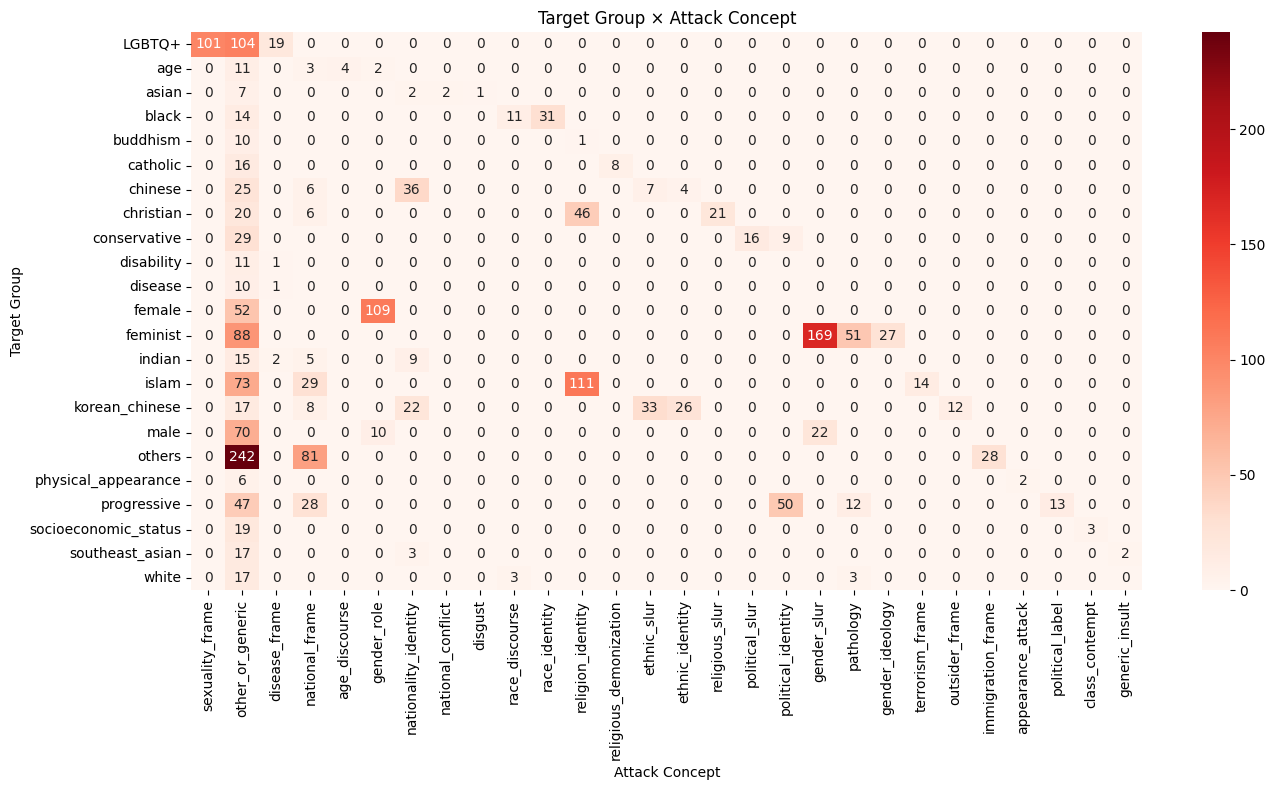

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

sns.heatmap(
    concept_df,
    cmap="Reds",
    annot=True,
    fmt="d"
)

plt.title("Target Group × Attack Concept")
plt.xlabel("Attack Concept")
plt.ylabel("Target Group")
plt.tight_layout()
plt.show()

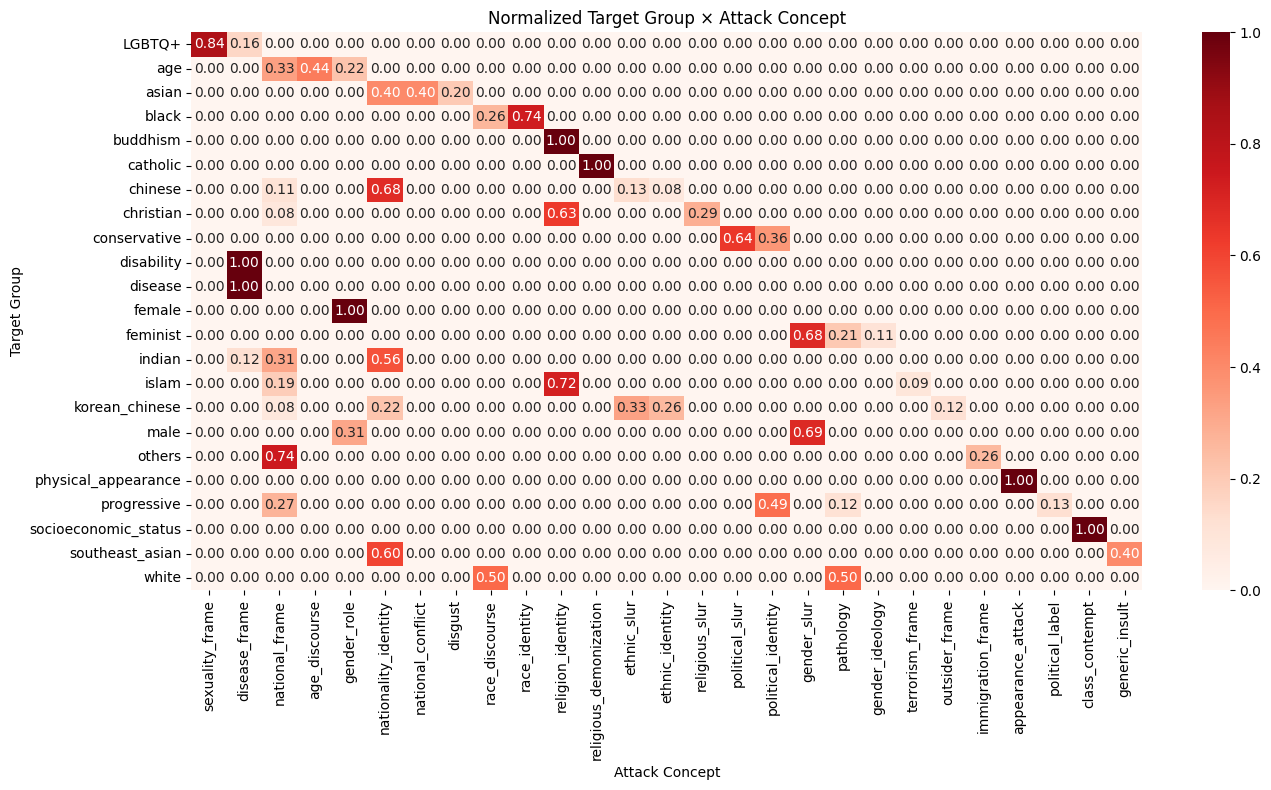

In [66]:
plot_df = concept_df.copy()

if 'other_or_generic' in plot_df.columns:
    plot_df = plot_df.drop(columns=['other_or_generic'])

row_norm_df = plot_df.div(plot_df.sum(axis=1), axis=0).fillna(0)

plt.figure(figsize=(14, 8))

sns.heatmap(
    row_norm_df,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

plt.title("Normalized Target Group × Attack Concept")
plt.xlabel("Attack Concept")
plt.ylabel("Target Group")
plt.tight_layout()
plt.show()

In [71]:
# 3시 46분 concept 수정한 버전

new_concept_map = {
    # -------------------------
    # 1) pathology
    # -------------------------
    "정신병": "pathology",
    "정신병이다": "pathology",
    "정신병자": "pathology",
    "정신병자들": "pathology",
    "미친": "pathology",
    "미쳤네": "pathology",
    "정신": "pathology",
    "정신나간": "pathology",
    "답없다": "pathology",

    # -------------------------
    # 2) disease
    # -------------------------
    "에이즈": "disease",
    "인권타령에이즈": "disease",
    "코로나": "disease",

    # -------------------------
    # 3) terrorism
    # -------------------------
    "테러": "terrorism",
    "탈레반": "terrorism",
    "달레반": "terrorism",  # 혹시 오타/변형 포함

    # -------------------------
    # 4) disgust
    # -------------------------
    "역겹다": "disgust",
    "역겨운": "disgust",
    "극혐": "disgust",
    "추하다": "disgust",
    "꼬라지": "disgust",
    "꼬라지하고는": "disgust",
    "ㅉㅉㅉ": "disgust",
    "웃기네": "disgust",
    "한심하다": "disgust",
    "한심": "disgust",
    "무식": "disgust",
    "무식한": "disgust",

    # -------------------------
    # 5) dehumanization
    # -------------------------
    "기생충": "dehumanization",
    "사회악": "dehumanization",
    "사회악이다": "dehumanization",
    "벌레": "dehumanization",
    "쓰레기들": "dehumanization",

    # -------------------------
    # 6) criminalization
    # -------------------------
    "사기꾼": "criminalization",
    "성추행범": "criminalization",
    "범죄자": "criminalization",
    "범죄": "criminalization",

    # -------------------------
    # 7) outsider
    # -------------------------
    "꺼져": "outsider",
    "가라": "outsider",
    "나라로": "outsider",
    "중국으로": "outsider",
    "한국으로": "outsider",
    "국적": "outsider",
    "난민": "outsider",
    "동포라고": "outsider",   # 문맥상 배제/부정 맥락에서 자주 쓰이면 유지
    "동포라": "outsider",
    "대한민국": "outsider",   # 배제/귀속 논쟁 맥락에서만 의미 있음
    "한국": "outsider",       # 너무 넓어서 나중에 문맥 보고 제거 가능
    "나라": "outsider",       # 이것도 과포괄 가능
    "나라를": "outsider",
    "나라가": "outsider",

    # -------------------------
    # 8) role_stereotype
    # -------------------------
    "군대": "role_stereotype",
    "여자": "role_stereotype",
    "여자는": "role_stereotype",
    "여자가": "role_stereotype",
    "여성": "role_stereotype",
    "남자": "role_stereotype",
    "남자가": "role_stereotype",
    "남자들": "role_stereotype",
    "유리천장": "role_stereotype",
    "유리천장이": "role_stereotype",

    # -------------------------
    # 9) ideological_label
    # -------------------------
    "좌파": "ideological_label",
    "민주당": "ideological_label",
    "더불어": "ideological_label",
    "정권": "ideological_label",
    "국짐당": "ideological_label",
    "국짐": "ideological_label",
    "국민의": "ideological_label",
    "후보": "ideological_label",
    "문재앙": "ideological_label",
    "빨갱이": "ideological_label",
    "빨갱이들": "ideological_label",
    "대깨문": "ideological_label",
    "악법": "ideological_label",
    "기레기": "ideological_label",
    "남혐": "ideological_label",
    "페미니즘": "ideological_label",
    "페미니즘은": "ideological_label",
    "페미니스트": "ideological_label",
    "젠더": "ideological_label",

    # -------------------------
    # 10) generic_insult
    # -------------------------
    "쓰레기": "generic_insult",
    "개소리": "generic_insult",
    "페미": "generic_insult",
    "페미가": "generic_insult",
    "페미들": "generic_insult",
    "페미는": "generic_insult",
    "페미들이": "generic_insult",
    "페미를": "generic_insult",
    "페미들아": "generic_insult",
    "페미들은": "generic_insult",
    "메갈": "generic_insult",
    "꼴페미": "generic_insult",
    "한남": "generic_insult",
    "한남들": "generic_insult",
    "개독": "generic_insult",
    "개독교": "generic_insult",
    "짱깨": "generic_insult",
    "조선족": "generic_insult",
    "조선족은": "generic_insult",
    "대머리네": "generic_insult",
    "대머리여": "generic_insult",
    "썩은": "generic_insult",
    "썩어빠진": "generic_insult",
}

In [74]:
identity_map = {
    "feminist": "gender",
    "female": "gender",
    "male": "gender",
    "LGBTQ+": "gender",   # 엄밀히는 sexuality/gender minority지만 네 현재 taxonomy에선 gender 축에 포함 가능

    "islam": "religion",
    "christian": "religion",
    "catholic": "religion",
    "buddhism": "religion",

    "black": "race_ethnicity",
    "white": "race_ethnicity",
    "asian": "race_ethnicity",

    "chinese": "nationality",
    "korean_chinese": "nationality",
    "indian": "nationality",
    "southeast_asian": "nationality",

    "progressive": "politics",
    "conservative": "politics",

    "age": "age",
    "socioeconomic_status": "class",
    "disability": "disability",
    "physical_appearance": "appearance",
}

In [76]:
from collections import Counter, defaultdict
import pandas as pd

grp_concept_counts = {}
unmapped_tokens = defaultdict(list)

for grp, word_list in grp_vocab.items():
    concept_counter = Counter()

    for word, cnt in word_list:
        norm = normalize_token(word)

        # 1️⃣ seed concept mapping
        if word in new_concept_map:
            concept = new_concept_map[word]

        elif norm in new_concept_map:
            concept = new_concept_map[norm]
        # 2️⃣ rule-based fallback (taxonomy 기준)
        elif "페미" in norm or "메갈" in norm or "한남" in norm:
            concept = "generic_insult"

        elif "동성애" in norm:
            concept = "ideological_label"

        elif "정신병" in norm or "미친" in norm:
            concept = "pathology"

        elif "에이즈" in norm or "코로나" in norm:
            concept = "disease"

        elif "테러" in norm or "탈레반" in norm:
            concept = "terrorism"

        elif "역겹" in norm or "극혐" in norm or "혐오" in norm:
            concept = "disgust"

        elif "쓰레기" in norm or "기생충" in norm:
            concept = "dehumanization"

        elif "사기꾼" in norm or "범죄" in norm:
            concept = "criminalization"

        elif "난민" in norm or "나라로" in norm or "국적" in norm:
            concept = "outsider"

        elif "여자" in norm or "여성" in norm or "남자" in norm or "군대" in norm:
            concept = "role_stereotype"

        elif "좌파" in norm or "민주당" in norm or "국짐" in norm:
            concept = "ideological_label"

        else:
            concept = "generic_insult"
            unmapped_tokens[grp].append((word, cnt))

        concept_counter[concept] += cnt

    grp_concept_counts[grp] = concept_counter


# DataFrame으로 정리
concept_df = pd.DataFrame(grp_concept_counts).fillna(0).astype(int).T
concept_df

,disease,pathology,generic_insult,ideological_label,role_stereotype,criminalization,outsider,disgust,terrorism
LGBTQ+,32,21,185,14,0,0,0,0,0
age,0,0,20,0,2,0,0,0,0
asian,0,0,17,0,0,0,0,0,0
black,0,0,54,0,0,2,0,0,0
buddhism,0,0,15,0,0,0,0,0,0
catholic,0,0,39,0,0,0,0,0,0
chinese,5,0,52,0,0,0,15,0,0
christian,0,4,92,0,0,0,0,0,0
conservative,0,3,40,7,0,0,0,0,0
disability,1,0,17,0,0,0,0,0,0


In [77]:
concept_df["total"] = concept_df.sum(axis=1)
concept_df = concept_df.sort_values("total", ascending=False)

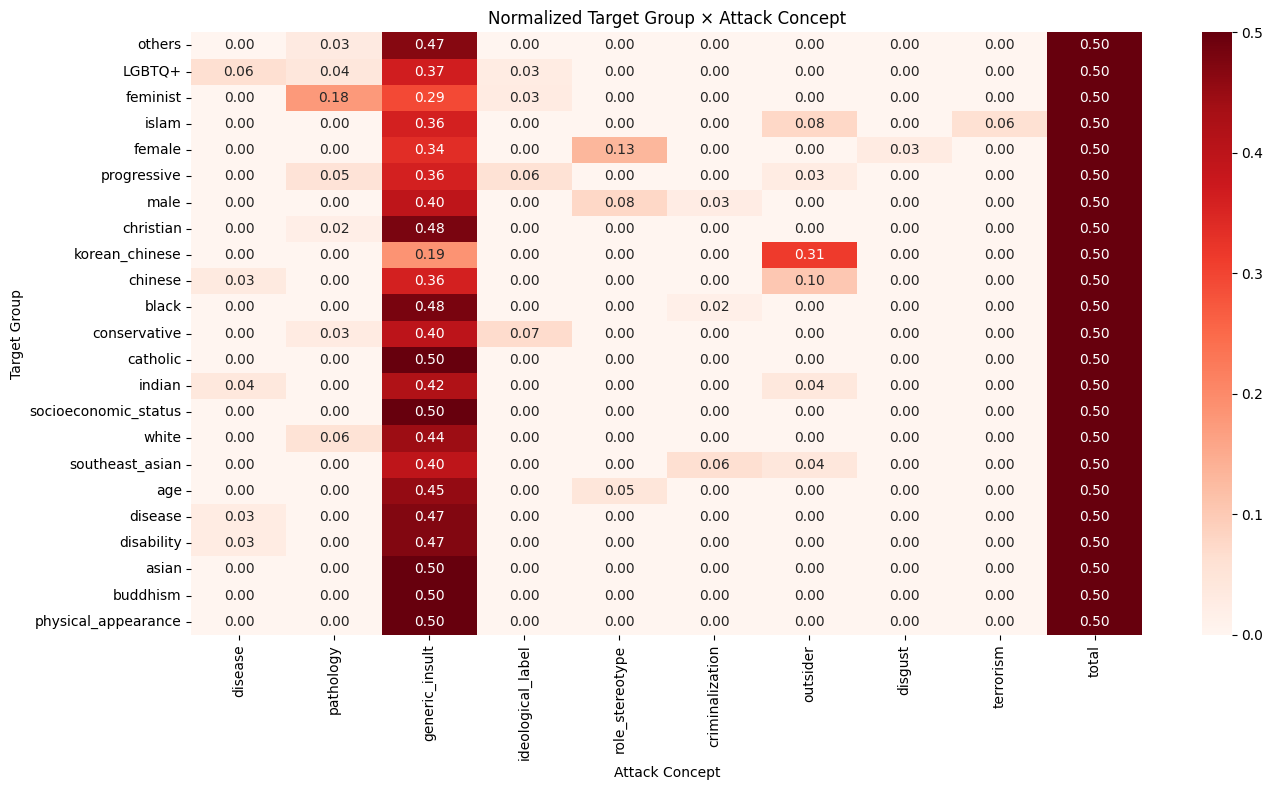

In [ ]:
plot_df = concept_df.copy()

if 'other_or_generic' in plot_df.columns:
    plot_df = plot_df.drop(columns=['other_or_generic'])

row_norm_df = plot_df.div(plot_df.sum(axis=1), axis=0).fillna(0)

plt.figure(figsize=(14, 8))

sns.heatmap(
    row_norm_df,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

plt.title("Normalized Target Group × Attack Concept")
plt.xlabel("Attack Concept")
plt.ylabel("Target Group")
plt.tight_layout()
plt.show()

In [ ]:
# 정규화
concept_df_norm = concept_df.div(concept_df.sum(axis=1), axis=0)

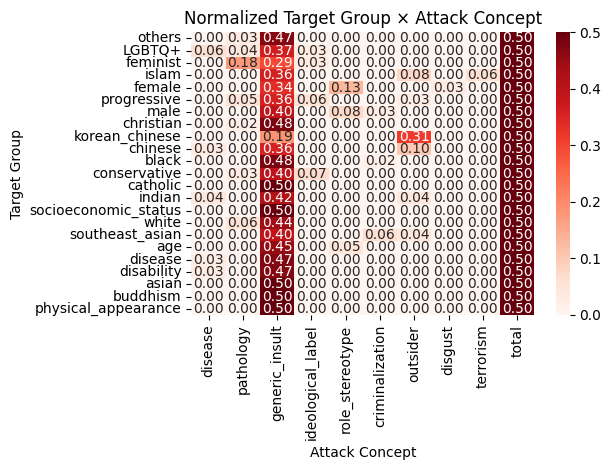

In [82]:
sns.heatmap(concept_df_norm,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

plt.title("Normalized Target Group × Attack Concept")
plt.xlabel("Attack Concept")
plt.ylabel("Target Group")
plt.tight_layout()
plt.show()

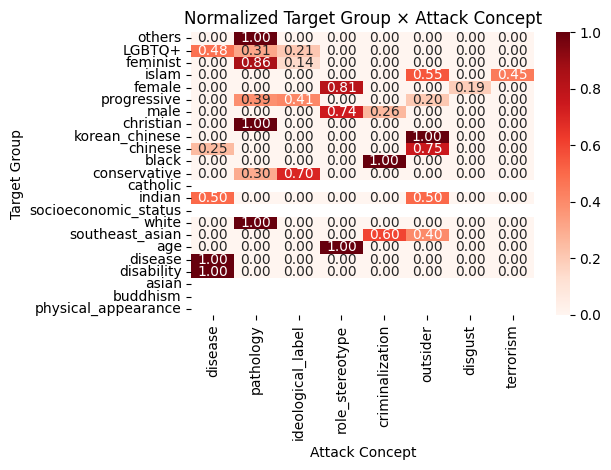

In [84]:
concept_df_no_generic = concept_df.drop(columns=["generic_insult", "total"])

concept_df_no_generic_norm = concept_df_no_generic.div(
    concept_df_no_generic.sum(axis=1), axis=0
)

sns.heatmap(
    concept_df_no_generic_norm,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

plt.title("Normalized Target Group × Attack Concept")
plt.xlabel("Attack Concept")
plt.ylabel("Target Group")
plt.tight_layout()
plt.show()

In [85]:
concept_df_no_generic.sum(axis=1)

others                  20
LGBTQ+                  67
feminist                97
islam                   56
female                  53
progressive             44
male                    23
christian                4
korean_chinese          59
chinese                 20
black                    2
conservative            10
catholic                 0
indian                   6
socioeconomic_status     0
white                    3
southeast_asian          5
age                      2
disease                  1
disability               1
asian                    0
buddhism                 0
physical_appearance      0
dtype: int64

In [86]:
# 각 group에서 가장 많이 등장한 attack frame
top_frame = concept_df_no_generic.idxmax(axis=1)

# 해당 frame의 값도 같이 보기
top_value = concept_df_no_generic.max(axis=1)

top_attack = pd.DataFrame({
    "Top_Attack_Frame": top_frame,
    "Count": top_value
})

top_attack

,Top_Attack_Frame,Count
others,pathology,20
LGBTQ+,disease,32
feminist,pathology,83
islam,outsider,31
female,role_stereotype,43
progressive,ideological_label,18
male,role_stereotype,17
christian,pathology,4
korean_chinese,outsider,59
chinese,outsider,15


In [87]:
# normalized 데이터 기준
top_frame = concept_df_no_generic_norm.idxmax(axis=1)
top_value = concept_df_no_generic_norm.max(axis=1)

top_attack = pd.DataFrame({
    "Top_Attack_Frame": top_frame,
    "Ratio": top_value
})

top_attack

C:\Users\82109\AppData\Local\Temp\ipykernel_20232\1614802468.py:2: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  top_frame = concept_df_no_generic_norm.idxmax(axis=1)


,Top_Attack_Frame,Ratio
others,pathology,1.000000
LGBTQ+,disease,0.477612
feminist,pathology,0.855670
islam,outsider,0.553571
female,role_stereotype,0.811321
progressive,ideological_label,0.409091
male,role_stereotype,0.739130
christian,pathology,1.000000
korean_chinese,outsider,1.000000
chinese,outsider,0.750000


1) 먼저 신뢰도 필터

아까 네가 준 N 기준으로 N ≥ 10 정도만 “의미 있는 패턴”으로 보자.

신뢰 가능한 그룹들:

feminist (97) → pathology (83, 0.86)

LGBTQ+ (67) → disease (32, 0.48)

korean_chinese (59) → outsider (59, 1.00)

islam (56) → outsider (31, 0.55)

female (53) → role_stereotype (43, 0.81)

progressive (44) → ideological_label (18, 0.41)

male (23) → role_stereotype (17, 0.74)

others (20) → pathology (20, 1.00) ← 해석은 애매

chinese (20) → outsider (15, 0.75)

conservative (10) → ideological_label (7, 0.70)

N 작은 그룹(≤5)은 참고만:
christian, black, white, age, disability 등.

2) 지금 데이터에서 보이는 “프레임 패턴”

이건 꽤 정형적인 구조다.

Gender

female → role_stereotype (0.81)

male → role_stereotype (0.74)

➡ gender attack은 stereotype framing

Ethnicity / nationality

korean_chinese → outsider (1.00)

chinese → outsider (0.75)

➡ ethnic minority → outsider framing

Religion

islam → outsider (0.55)

(terrorism도 일부 있었을 가능성)

➡ religion → threat / outsider framing

Political identity

progressive → ideological_label

conservative → ideological_label

➡ politics → labeling attack

Feminism

feminist → pathology (0.86)

➡ “정신병 framing”

이건 한국 온라인 담론에서 엄청 흔한 패턴이다.

LGBTQ+

LGBTQ+ → disease (0.48)

이거 꽤 흥미로운 결과다.

➡ sexuality → disease framing

즉

동성애 = 질병 / 에이즈

같은 discourse.

3) 그래서 이 데이터를 한 문장으로 요약하면

Different social identities receive different hate frames.

예:

gender → stereotype
ethnicity → outsider
politics → ideological labeling
feminism → pathology
sexuality → disease

이건 사실 hate framing typology 수준이다

### Offensive span 분석
=> 욕설 강도나 길이라디 보다는, annotation 기준
=> 뚜렷한 분석 결과는 나오지 않음.

In [52]:
single_df = df[~df['GRP'].astype(str).str.contains('&', na=False)].copy()

In [53]:
single_df['GRP_clean'] = single_df['GRP'].str.split('-').str[-1]

In [54]:
single_df['span_len'] = single_df['OFF_span'].astype(str).apply(lambda x: len(x.split()))

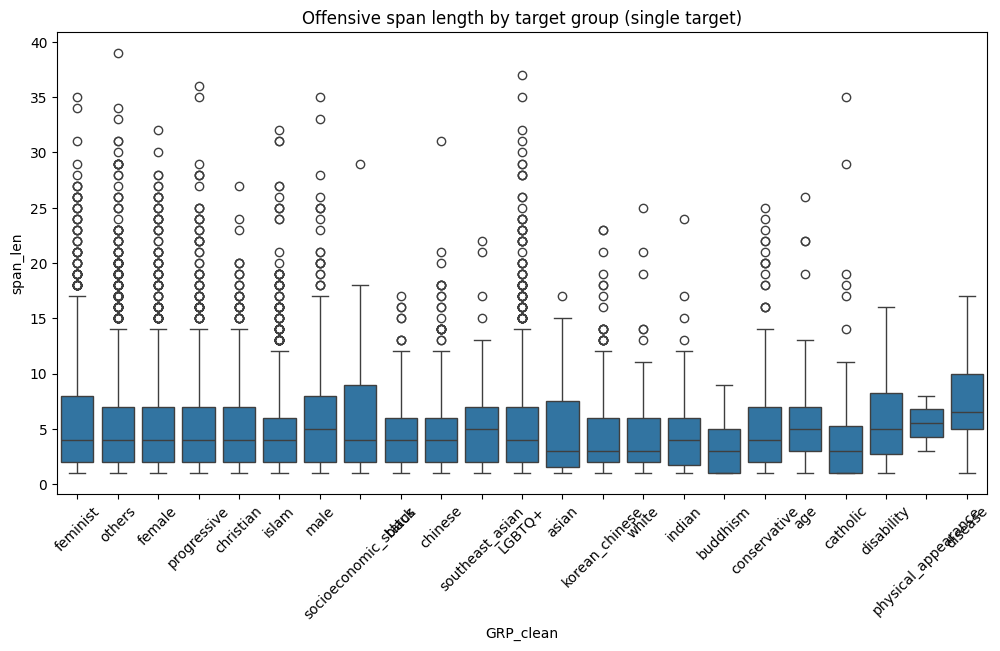

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    data=single_df,
    x='GRP_clean',
    y='span_len'
)

plt.xticks(rotation=45)
plt.title("Offensive span length by target group (single target)")
plt.show()